# Cell-Type Annotation with LLM: A Step-by-Step Tutorial

This notebook demonstrates how to perform cell-type annotation on spatial transcriptomics data (Xenium, FFPE human breast) using Scanpy and an LLM (e.g., OpenAI GPT) for automatic cluster labeling. You’ll learn how to:

1. Set up the environment and load a sample dataset.
2. Cluster cells with Scanpy (Leiden) and extract top marker genes.
3. Use an LLM to assign cell-type labels to each cluster.
4. Visualize the annotated results (UMAP) and inspect top marker genes per annotated cell type.

Replace `API_KEY` with your own OpenAI key to run LLM annotation.

In [1]:
# Cell 1: Notebook Setup
# ----------------------

# Install requirements if necessary (uncomment if needed)
# !pip install scanpy openai anndata tic

import scanpy as sc
import warnings
warnings.filterwarnings("ignore")

# Set Scanpy verbosity and plotting defaults
sc.settings.verbosity = 2
sc.set_figure_params(figsize=(5, 5), dpi=100)


## Load the Dataset

You can load your own data (e.g., `adata = sc.read_h5ad("path/to/file.h5ad")`), or use a built-in example. Here, we use the `tic.data.load_xenium_dataset` helper to fetch a sample Xenium kidney cancer dataset.

In [2]:
# Cell 2: Load Dataset
# --------------------

from tic.data import load_xenium_dataset

adata = load_xenium_dataset(name='xenium_kidney_cancer')
adata

# Provide a description of the dataset to include in the LLM prompt
DATASET_DESCRIPTION = """
Xenium In Situ gene expression profiling of adult human kidney tissue diagnosed with papillary renal cell carcinoma (PRCC), using a development version of the Xenium Human Multi-Tissue and Cancer Panel.
The FFPE tissue microstrip was purchased from AcePix Biosciences and represents a cancerous kidney section (PRCC). Tissue preparation followed the demonstrated protocols Xenium In Situ for FFPE - Tissue Preparation Guide (CG000578) and Xenium In Situ for FFPE Tissues – Deparaffinization & Decrosslinking (CG000580).
Post-instrument processing followed the Xenium In Situ Gene Expression - Post-Xenium Analyzer H&E Staining protocol (CG000613).
Gene expression was measured using the Xenium Human Multi-Tissue and Cancer Panel (377 genes), designed by 10x Genomics based on standardized single-cell RNA-seq data from the Human Protein Atlas. The panel includes genes for cell typing, immune markers, proliferation, and tumor profiling across multiple tissues, including kidney.
The dataset was processed using the Xenium Analyzer with Onboard Analysis version 1.5.0.
Summary metrics for the PRCC region:
- Cells detected: 56,510
- Median transcripts per cell: 57
- High-quality transcripts: 4,052,443
- Region area: 17,102,908 µm²
- Decoded transcripts per 100 µm²: 36.3
This dataset enables spatially resolved analysis of cancer-associated gene expression in human kidney tissue.
"""


Xenium dataset 'xenium_kidney_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer
2025-06-05 12:44:59,082 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_kidney_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer


reading /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer/cell_feature_matrix.h5
 (0:00:00)


2025-06-05 12:44:59,426 INFO Loaded xenium_kidney_cancer: 56510 cells * 541 genes.
2025-06-05 12:44:59,426 | INFO     | tic.data.xenium.loader | Loaded xenium_kidney_cancer: 56510 cells * 541 genes.


## Run Full Annotation Pipeline

This step performs:
1. Preprocessing (filtering, normalization, PCA, neighbors, Leiden).
2. Ranking top marker genes per Leiden cluster.
3. Querying an LLM to assign cell-type labels to each cluster.
4. Mapping those labels back to each cell in `adata.obs['pred_cell_type']`.

Make sure to set your `API_KEY` (e.g., in `utils.config.API_KEY`).

In [3]:
# Cell 3: Run Full Annotation Pipeline
# ------------------------------------

from tic.annotation import annotate_adata
from utils.config import API_KEY  # Replace with your own key

adata_pred, cluster_annotation = annotate_adata(
    adata=adata,
    assign_params={
        "min_cells": 0,
        "min_genes": 0,
        "n_pca": 50,
        "n_neighbors": 15,
        "resolution": 2.0,
        "n_filter_highly_variable_genes": 2000,
    },
    llm_model_name="openai",
    llm_kwargs={"api_key": API_KEY, "mirror": True},
    dataset_description=(
        DATASET_DESCRIPTION +
        "This dataset contains tumor cells. Please ensure at least one cluster is annotated as tumor."
    ),
    groupby="leiden",
    rank_genes_groups_method="t-test",
    n_genes=10,
    copy=True,
    return_cluster_annotation=True,
)

import json
print("Cluster → Assigned Cell Type:")
print(json.dumps(cluster_annotation, indent=2))


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:11)
running Leiden clustering
    finished (0:01:06)
computing UMAP
    finished (0:00:20)
ranking genes


... storing 'feature_types' as categorical
... storing 'genome' as categorical


    finished (0:00:00)


2025-06-05 12:47:03,610 INFO Saved cell-type cache to /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer/xenium_kidney_cancer_llm_cell_types.parquet
2025-06-05 12:47:03,610 | INFO     | tic.annotation.api | Saved cell-type cache to /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer/xenium_kidney_cancer_llm_cell_types.parquet


Cluster → Assigned Cell Type:
{
  "0": {
    "assigned_cell_type": "CD8+ Cytotoxic T cell",
    "reasoning": "Markers include CD8A, CD3E/D, TRAC, GZMK, GZMA, CCL5, and NKG7\u2014all classic markers for cytotoxic CD8+ T cells, which mediate cellular immunity via cytotoxic granules (granzymes, perforin) and express T-cell receptors."
  },
  "1": {
    "assigned_cell_type": "Monocyte-derived Macrophage",
    "reasoning": "High expression of CD14, FCGR3A (CD16), CD68, CD163, AIF1, MS4A6A, and MS4A4A are canonical myeloid markers found on monocytes/macrophages; CD14 and FCGR3A in particular indicate non-classical/activated monocytes or macrophages."
  },
  "2": {
    "assigned_cell_type": "CD4+ T cell (Naive/Memory)",
    "reasoning": "High IL7R, TRAC, CD3E/D, CD28, CD2, and SELL (L-selectin) suggest T lineage; absence of CD8A and presence of IL7R and SELL indicate a CD4+ T (non-cytotoxic, possibly naive or memory) profile."
  },
  "3": {
    "assigned_cell_type": "Exhausted CD8+ T cell",
 

## Visualize Annotation Results

Plot UMAP embeddings colored by:
1. Original Leiden cluster (`adata.obs['leiden']`).
2. LLM-predicted cell type (`adata.obs['pred_cell_type']`).

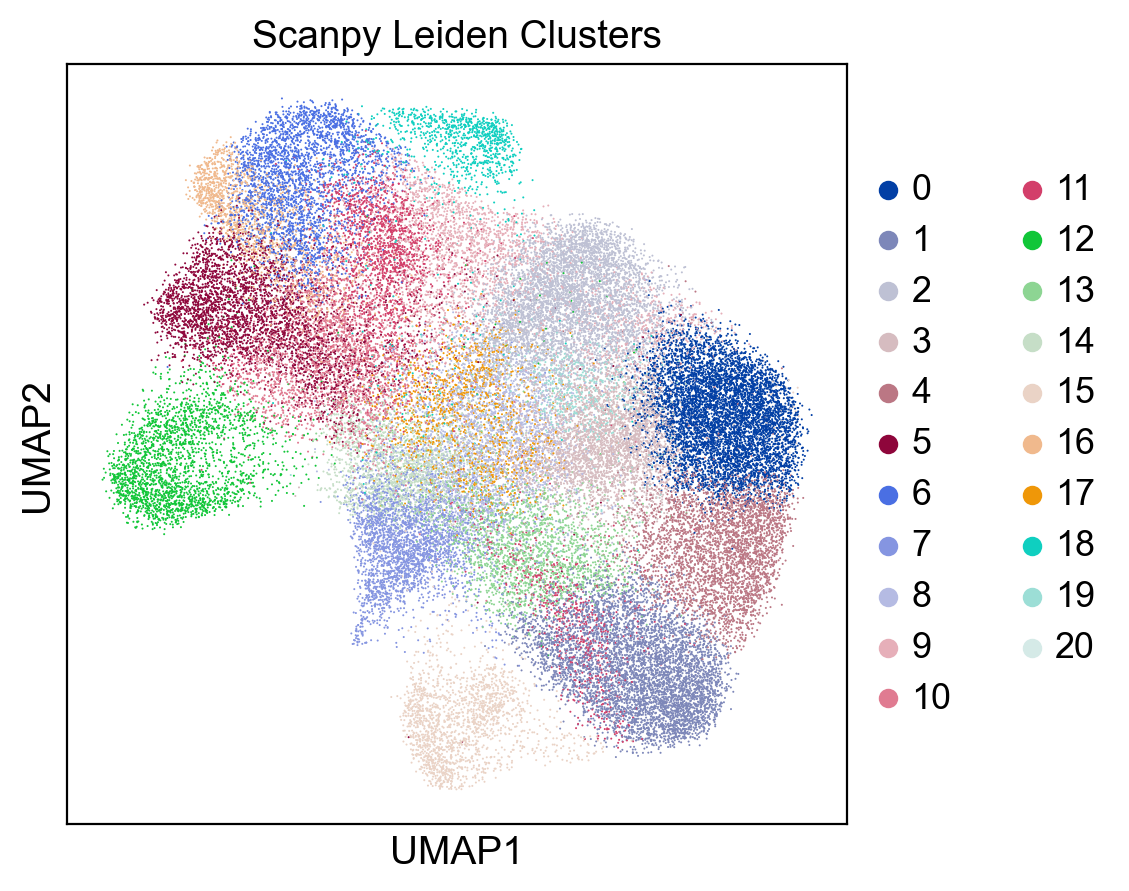

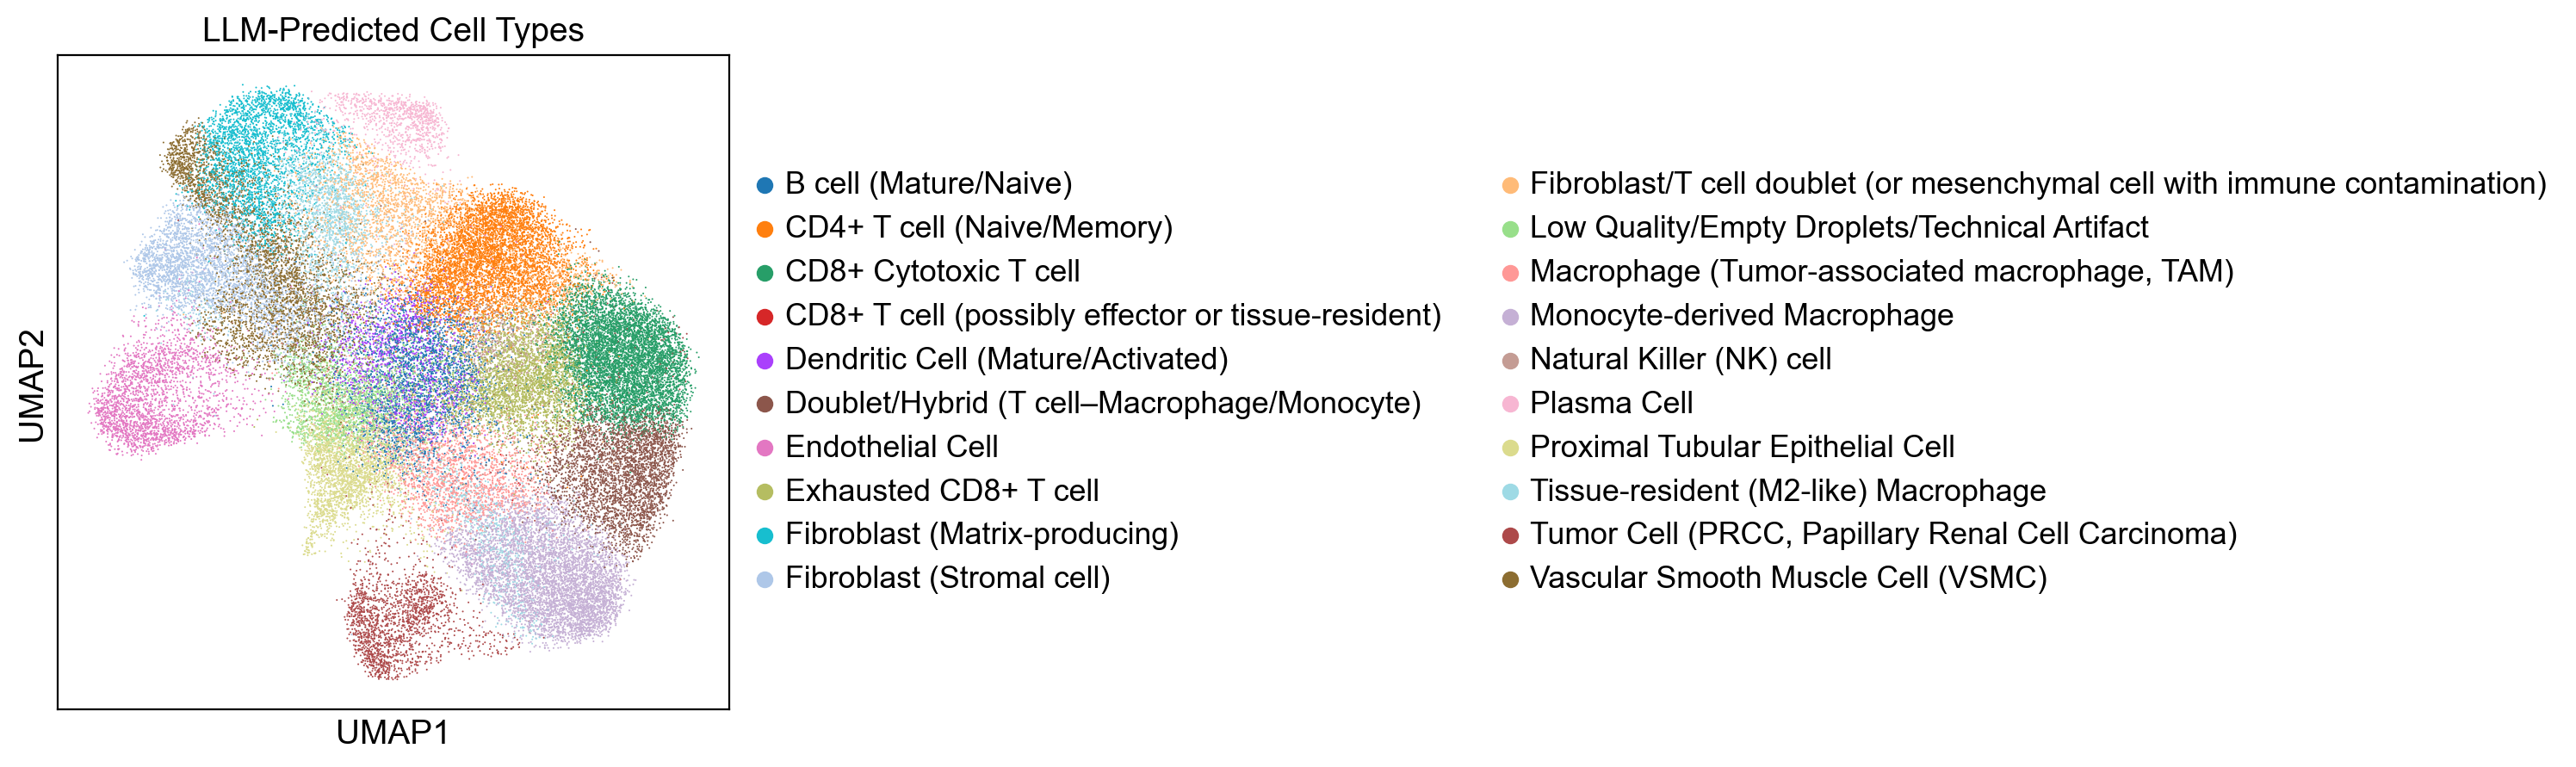

In [4]:
# Cell 4: Visualize Annotation Results
# ------------------------------------

# Plot UMAP colored by original Leiden clusters
sc.pl.umap(adata_pred, color=["leiden"], title="Scanpy Leiden Clusters")

# Plot UMAP colored by LLM-predicted cell types
sc.pl.umap(adata_pred, color=["pred_cell_type"], title="LLM-Predicted Cell Types")


## Rank Marker Genes by Predicted Cell Type

Now that each cell has a `pred_cell_type` label, let’s re-rank marker genes across those groups. This lets us see the top genes per annotated cell type rather than per Leiden cluster.

In [5]:
# Cell 5: Rank Genes by Predicted Cell Type
# ------------------------------------------

n_genes = 5  # number of top genes per cell type to extract
sc.tl.rank_genes_groups(
    adata_pred,
    groupby="pred_cell_type",
    method="t-test",         # or "wilcoxon", etc.
    n_genes=n_genes,
    key_added="rank_genes_by_pred"  # stored in adata_pred.uns
)


ranking genes
    finished (0:00:00)


## Build a DataFrame of Top Genes + Scores

Extract the `names` and `scores` from `adata_pred.uns['rank_genes_by_pred']`, then combine into a single DataFrame for easy inspection.

In [6]:
# Cell 6: Extract Top Genes into a Pandas DataFrame
# -------------------------------------------------

import pandas as pd

# Grab the Scanpy result object
result = adata_pred.uns["rank_genes_by_pred"]
cell_types = result["names"].dtype.names  # tuple of each predicted cell_type

dfs = []
for ct in cell_types:
    genes = result["names"][ct][:n_genes].tolist()
    scores = result["scores"][ct][:n_genes].tolist()
    df_temp = pd.DataFrame({
        "cell_type": ct,
        "gene": genes,
        "score": scores
    })
    dfs.append(df_temp)

df_top = pd.concat(dfs, ignore_index=True)
df_top


,cell_type,gene,score
0,B cell (Mature/Naive),PTPRC,121.290001
1,B cell (Mature/Naive),MS4A1,5.763483
2,B cell (Mature/Naive),BANK1,5.555857
3,B cell (Mature/Naive),GNLY,4.239204
4,B cell (Mature/Naive),SELL,3.410957
...,...,...,...
95,Vascular Smooth Muscle Cell (VSMC),ACTA2,81.530533
96,Vascular Smooth Muscle Cell (VSMC),MYLK,76.298584
97,Vascular Smooth Muscle Cell (VSMC),MYH11,72.504662
98,Vascular Smooth Muscle Cell (VSMC),CAVIN1,56.464130


## Visualize Top Genes per Cell Type

Define a helper function to plot, for each `pred_cell_type`, a horizontal bar chart of its top marker genes and scores.

In [7]:
# Cell 7: Define Plotting Function
# -------------------------------

import matplotlib.pyplot as plt
import numpy as np

def plot_top_genes_by_celltype(
    adata,
    key_for_rank="rank_genes_by_pred",
    n_genes=5,
    figsize_per_cell=(4, 2),
    title_suffix=""
):
    """
    Plot the top N genes (+ scores) for each cell type, as horizontal bar charts.
    
    Parameters
    ----------
    adata : AnnData
        Must have `adata.uns[key_for_rank]` present (from sc.tl.rank_genes_groups).
    key_for_rank : str
        Where Scanpy stored rank_genes_groups results (e.g. "rank_genes_by_pred").
    n_genes : int
        How many top genes to plot per cell type.
    figsize_per_cell : tuple
        (width, height) of each subplot. Actual figure size will be
        (width, height * n_cell_types).
    title_suffix : str
        Optional string appended to each subplot’s title.
    """
    result = adata.uns[key_for_rank]
    cell_types = result["names"].dtype.names
    n_cells = len(cell_types)

    fig, axes = plt.subplots(
        n_cells, 1,
        figsize=(figsize_per_cell[0], figsize_per_cell[1] * n_cells),
        sharex=False
    )
    if n_cells == 1:
        axes = np.array([axes])

    for i, ct in enumerate(cell_types):
        genes = result["names"][ct][:n_genes][::-1]
        scores = result["scores"][ct][:n_genes][::-1]
        ax = axes[i]
        y_positions = np.arange(len(genes))
        ax.barh(y_positions, scores, color="steelblue")
        ax.set_yticks(y_positions)
        ax.set_yticklabels(genes, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel("Score", fontsize=10)
        ax.set_title(f"{ct} {title_suffix}", fontsize=12)
        ax.grid(axis="x", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


## Plot the Top 5 Marker Genes per Annotated Cell Type

Use the helper function defined above.

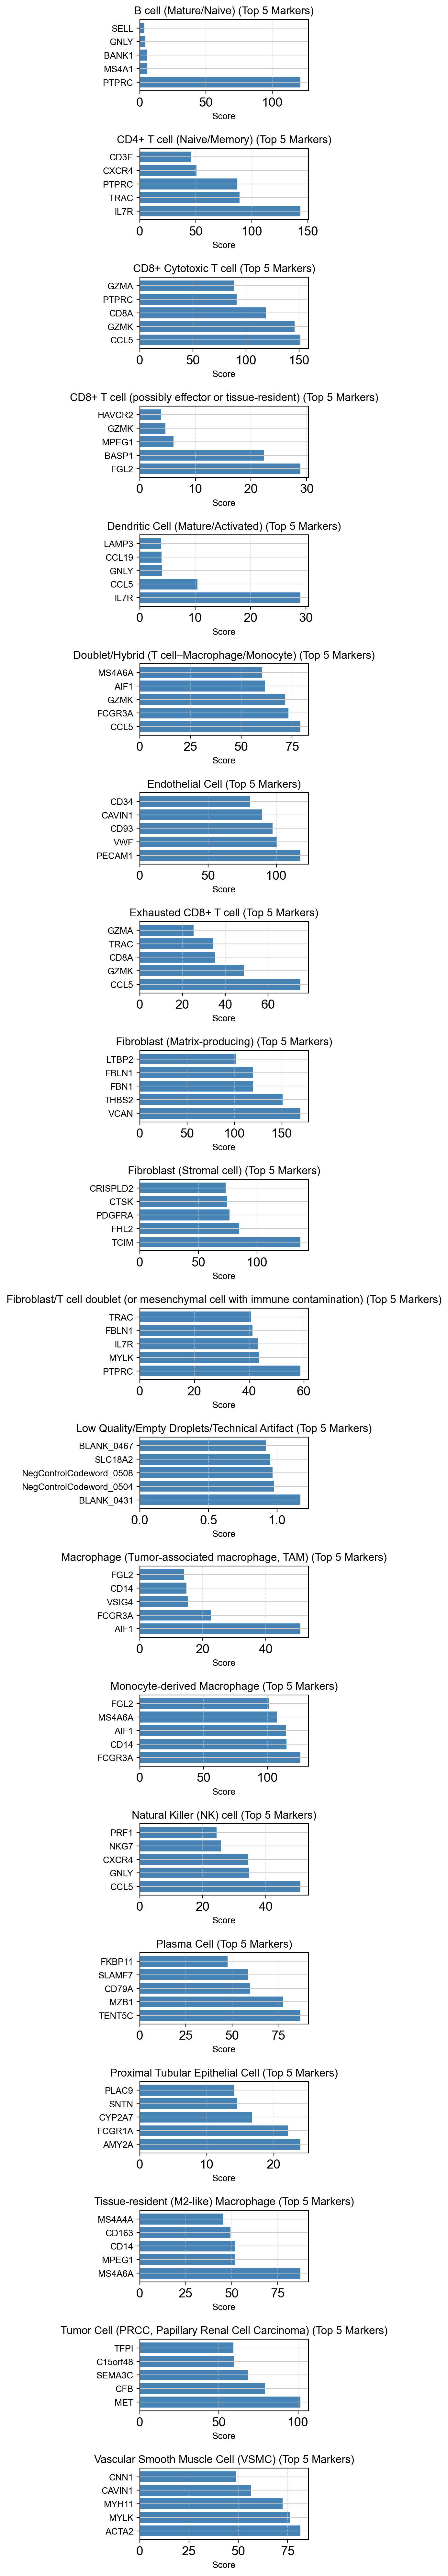

In [8]:
# Cell 8: Plot Top Genes
# ----------------------

plot_top_genes_by_celltype(
    adata_pred,
    key_for_rank="rank_genes_by_pred",
    n_genes=5,
    figsize_per_cell=(5, 2),
    title_suffix="(Top 5 Markers)"
)


### (Optional) Create a Wide Table of Top Genes + Scores per Cell Type

If you prefer a single table with columns `gene_1, score_1, gene_2, score_2, …`, you can pivot `df_top`.

In [9]:
# Cell 9: Pivot to Wide Format Table (Optional)
# --------------------------------------------

table_rows = []
for ct in df_top["cell_type"].unique():
    sub = df_top[df_top["cell_type"] == ct].reset_index(drop=True)
    row = {"cell_type": ct}
    for i in range(len(sub)):
        row[f"gene_{i+1}"] = sub.loc[i, "gene"]
        row[f"score_{i+1}"] = sub.loc[i, "score"]
    table_rows.append(row)

df_wide = pd.DataFrame(table_rows).set_index("cell_type")
df_wide


,gene_1,score_1,gene_2,score_2,gene_3,score_3,gene_4,score_4,gene_5,score_5
cell_type,,,,,,,,,,
B cell (Mature/Naive),PTPRC,121.290001,MS4A1,5.763483,BANK1,5.555857,GNLY,4.239204,SELL,3.410957
CD4+ T cell (Naive/Memory),IL7R,143.243896,TRAC,89.005135,PTPRC,86.901505,CXCR4,50.652676,CD3E,45.371189
CD8+ Cytotoxic T cell,CCL5,151.161438,GZMK,145.669037,CD8A,118.503967,PTPRC,91.233681,GZMA,88.639015
CD8+ T cell (possibly effector or tissue-resident),FGL2,28.867990,BASP1,22.371883,MPEG1,6.080834,GZMK,4.644611,HAVCR2,3.844430
Dendritic Cell (Mature/Activated),IL7R,28.997965,CCL5,10.429893,GNLY,4.021539,CCL19,3.917597,LAMP3,3.897463
Doublet/Hybrid (T cell–Macrophage/Monocyte),CCL5,79.108635,FCGR3A,73.156593,GZMK,71.587593,AIF1,61.744175,MS4A6A,60.234837
Endothelial Cell,PECAM1,117.607468,VWF,100.553665,CD93,97.334152,CAVIN1,89.751122,CD34,80.748009
Exhausted CD8+ T cell,CCL5,75.176872,GZMK,48.795704,CD8A,35.250473,TRAC,34.255512,GZMA,25.193569
Fibroblast (Matrix-producing),VCAN,169.644775,THBS2,150.872940,FBN1,119.675682,FBLN1,119.303986,LTBP2,101.688782


---
## Summary

In this tutorial, you have:
1. Loaded a Xenium spatial transcriptomics dataset.
2. Performed clustering with Scanpy (Leiden) and extracted top marker genes.
3. Used an LLM (e.g. OpenAI) to assign cell-type labels automatically.
4. Visualized UMAP colored by predicted cell types.
5. Re-ranked marker genes by predicted cell type and visualized them.

You can replace the dataset or customize `assign_params` / `n_genes` / the LLM model as needed. For large datasets or custom LLM backends, adjust the caching or timeout settings in `tic.annotation`.